# Blink Signals

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb)|<i>3.eeg_blink_signals.ipynb</i>|[4.alignment.ipynb](./4.alignment.ipynb)|

In the previous notebook [2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb), we attempted to derive blinks from VR data. That notebook generated a process to normalize signal data during the calibration phase, then use a peak/valley detection system. The functions relevant to that process are currently accessible in `src/components/blink_handling.py`. 

In THIS notebook, we will attempt to understand HOW blinks are recognized in the **Muse S** system and determine a way to align the data. The inspiration for this is that we've detected some unique signal patterns in the **TP9** and **TP10** channels of the Muse S. So let's actually explore what's going on here.

## Before We Begin: What Does the Literature Say?

According to [this paper (1985)](https://doi.org/10.1152/jn.1985.54.1.11), eye movements result in a downward, nasalward movement of the eyes during a blink gesture. These movements have shorter durations than the eyelid movement, and the movement of the eyes differ from that of the eyelids. Prolonged eye closure results in eye movements that drift upward or downward involuntarily, with a variable horizontal component. It is likely that transient eye movements are likely due to active muscle contractions rather than passive mechanisms of the eyelid. 

There is a mention of ["Bell's Phenomenon"](https://en.wikipedia.org/wiki/Bell%27s_phenomenon), which describes eye movements when an attempt to close the eyes are made. The previous paper mentions that Bell's Phenomenon has not been observed during short blinks. But what is Bell's Phenomenon? Bell's Phenomenon is defined as the following (simplified on Wikipedia, originally sourced by [this paper (2001)](https://pmc.ncbi.nlm.nih.gov/articles/PMC1121451/)):

> "[An] upward and outward movement of the eye, when an attempt is made to close the eyes. The upward movement of the eye is present in the majority of the population, and is a defensive mechanism."

[This video (2022)](https://www.youtube.com/watch?v=wxmBSyWD4mU&t=82s) elaborates that Bell's Phenomenon is a **defensive reflex** that occurs during **forced** eye closure (i.e. when something is about to hit your face and you force-close your eyes to protect them). It is not immediately clear from this video if Bell's Phenomenon is something that occurs **normally** during blinks.

[This report (2022)](https://isip.piconepress.com/conferences/ieee_spmb/2022/papers/l01_03.pdf) directly from the company that made Muse (supposedly) describes their algorithm for detecting blinks using single electrodes. They explain the same thing we've observed - that there's an aggressive valley accompanied by a smaller peak that's associated with a blink gesture. They use an algorithm that's actually kind of effective and makes very little assumptions about the signal behavior prior. They define the blink behavior as such:

> Eye-blinks are noticeable in EEG signal recordings, as seen in Figure 1, and can be described with respect to
the measured baseline voltage. The eye-blink starts with a steep drop in the measured voltage, representing the
closing of the eyelid. It is then followed by a steep rise that crosses the baseline and reaches higher voltages,
representing the opening of the eyelid. Finally, it is followed by a return to the measured baseline.

### Inferences to our work

I think at this point, it's safe to bet about the following:

- In the EEG signal, when the eye is closed, this corresponds to the largest detected valley. The signal will always return to the baseline (which can be measured based on the mean of the signal).
- If we want any blink alignment with other systems, then we need to time it in comparison to this minimum valley.

## Imports

In [64]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import importlib

from components import eeg_handling
importlib.reload(eeg_handling)

_DATA_DIR = 'data2'
_EXAMPLE_PARTICIPANT = 'P4_Muse2'

## Premise: Looking at EEG Data

Honestly, most participants' EEG data is pretty clean for our analysis. Before, in [2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb), we used `P4_Muse2` as our test case. Let's do the same and look at `P4_Muse2`'s EEG data - specifically, the `TP9` data (we could also look at the `TP10` channel, but it's mostly the same).

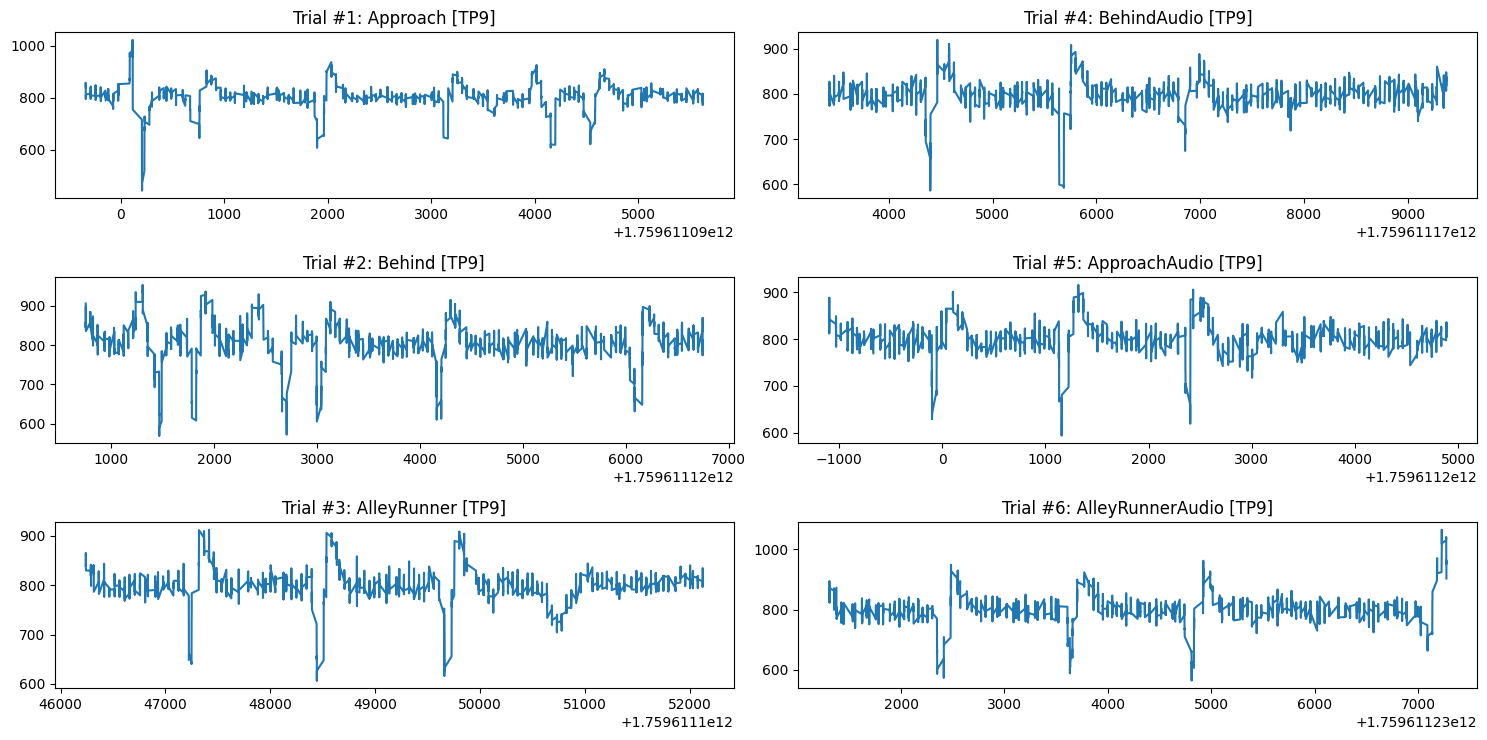

In [13]:
# Centralize to the particiapnt's directory
pdir = os.path.join('.', _DATA_DIR, _EXAMPLE_PARTICIPANT)

# Read the trial data
trials = pd.read_csv(os.path.join(pdir, "trials.csv"))

# Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
fig, axes = plt.subplots(3,2,figsize=(15,7.5))

# Iterate through trials
for _, row in trials.iterrows():

    # Read the eye data for each trial
    trial_id = row['trial_id']
    trial_name = row['trial_name']

    # Get the row and column indices in our figure
    row_index = math.floor((trial_id-1) % 3)
    col_index = math.floor((trial_id-1)/ 3)

    # Get the trial directory
    tdir = os.path.join(pdir, f"{trial_id}", 'calibration')

    # Read the necessary datasets'
    eeg_raw = pd.read_csv(os.path.join(tdir, 'eeg_raw.csv'))

    # From `eeg_raw`, get the start and end milliseconds. Then filter the rows of `eeg_raw`
    start_ms = eeg_raw['unix_ms'].iloc[0] + 5000
    end_ms = eeg_raw['unix_ms'].iloc[-1] - 500
    eeg = eeg_raw[eeg_raw['unix_ms'].between(start_ms, end_ms)]

    # Get x and y
    x = eeg['unix_ms'].to_list()
    y = eeg['TP9'].to_list()

    # Plot eeg data
    ax = axes[row_index][col_index]
    ax.plot(x, y)
    ax.set_title(f"Trial #{trial_id}: {trial_name} [TP9]")

# Show
plt.tight_layout()
plt.show()


Just looking at this data gives me the shivers. We can clearly identify the moments when the blink LIKELY happens, but the data is so noisy! I don't like doing this, but it is actually somewhat optimal to smooth the data before we do anything else.

## Exploration: Blink Samples

I went to record my own blink samples using our **Muse S** device - just to see the behavior of the EEG during specific blink characteristics. This data resides within `src/blink_samples/` and comprises of 2 blink samples.

In [59]:
_BLINK_SAMPLES_DIR = os.path.join('.', 'blink_samples/')
_BLINK_SAMPLES = [
    os.path.join(_BLINK_SAMPLES_DIR, 'sample_1.csv'),
    os.path.join(_BLINK_SAMPLES_DIR, 'sample_2.csv')
]

# load the raw samples as dataframes
raw_samples = [{'df':eeg_handling.separate(eeg_handling.read(s)[0])[0], 'name':os.path.basename(s)} for s in _BLINK_SAMPLES]

d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)


Now, let's attempt to render these in a 2x2 figure for easy plotting:

In [66]:
# The `savgol` will come into play later, trust me
def generate_figure(samples, figsize=(15,7.5), savgol=None):

    # Plot a figure to showcase the TP9s of these two samples
    fig, axes = plt.subplots(2,2,figsize=figsize)

    # Iterate through our two samples
    for i in range(len(samples)):
        df = samples[i]['df']
        x = df['unix_ms'].to_list()
        tp9 = df['TP9'].to_list()
        tp10 = df['TP10'].to_list()
        alpha = 1.0

        # if `savgol` is not None, then we know that we want to render the savgol filtered version on top of the original. So the original has to be set to a lower alpha
        if savgol is not None: alpha=0.25

        # Render the original data
        axes[i][0].plot(x, tp9, c='blue', alpha=alpha)
        axes[i][0].set_title(f"{samples[i]['name']}: TP9")
        axes[i][1].plot(x, tp10, c='orange', alpha=alpha)
        axes[i][1].set_title(f"{samples[i]['name']}: TP10")

        # Now render savgol-filtered data, if `savgol` is not None
        if savgol is not None:
            axes[i][0].plot(x, savgol(tp9), c='blue')
            axes[i][1].plot(x, savgol(tp10), c='orange')

        # If `blinks` is provided, then we plot them too
        if 'blinks_tp9' in samples[i] and samples[i]['blinks_tp9'] is not None:
            blink_sample = samples[i]['blinks_tp9']
            bx = blink_sample['x'].to_list()
            for bxi in bx:
                axes[i][0].axvline(x=bxi, c='red', alpha=0.5)
        if 'blinks_tp10' in samples[i] and samples[i]['blinks_tp10'] is not None:
            blink_sample = samples[i]['blinks_tp10']
            bx = blink_sample['x'].to_list()
            for bxi in bx:
                axes[i][1].axvline(x=bxi, c='steelblue', alpha=0.5)


    # Render the plot
    plt.tight_layout()
    plt.show()

And finally, render the plots

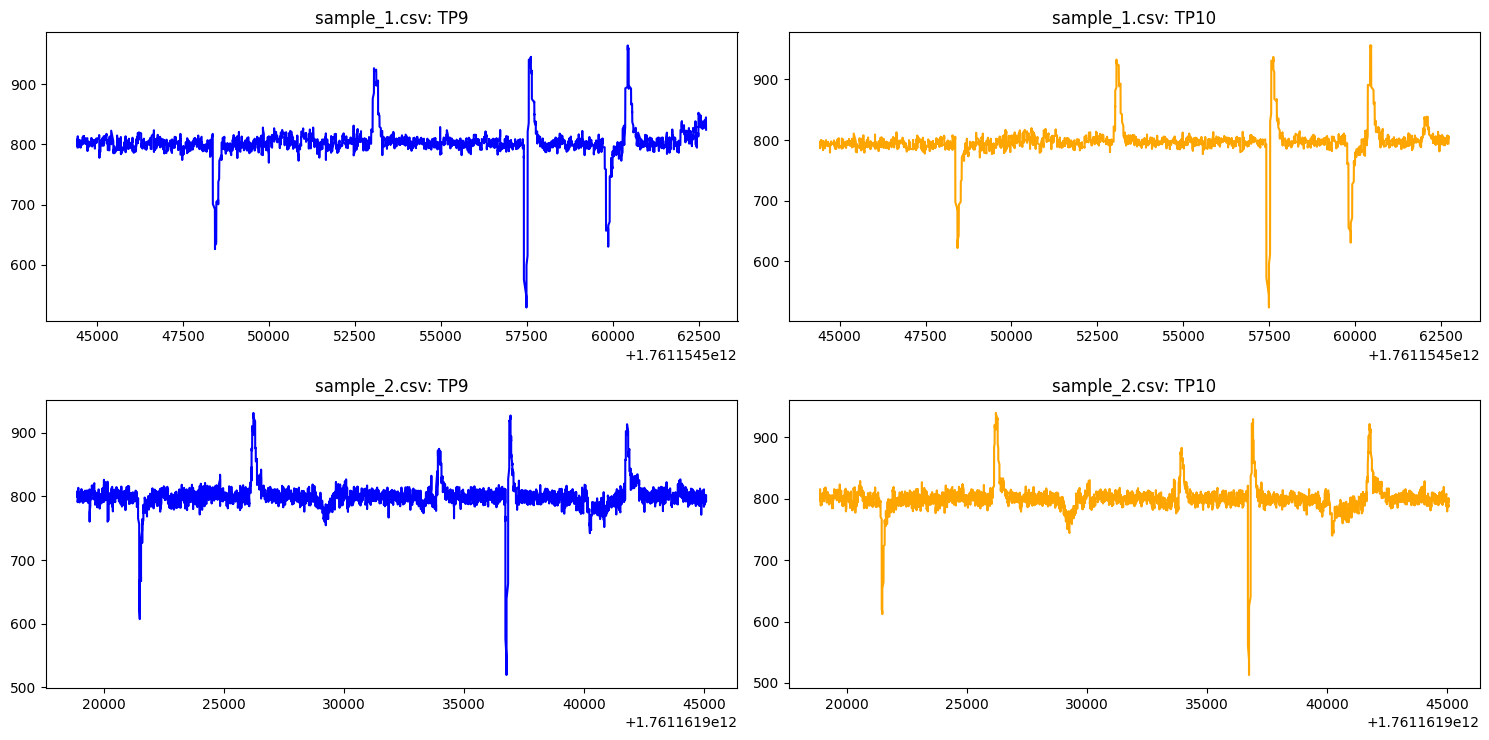

In [67]:
generate_figure(raw_samples)

### `sample_1.csv` (Top Row)

1. The first major VALLEY corresponds to the eye in a closing motion, and keeping them closed. It looks like, upon the blink being completed, the signal returns to its original median signal value even when the eye remains closed.
2. The first major PEAK corresponds to the eye opening after keeping it closed.
3. The first major valley => peak corresponds to a normal blink. It appears that the speed (or strength?) of the blink corresponds to the strength of the valley and only to the peak a little bit.
4. The second major valley => peak corresponds to a slower blink.
5. When the eyes are closed, upon closing, there's a little bit of a delay where the signal power in both TP9 and TP10 remain slightly _below_ the midline, but this only lasts for a few milliseconds. This is evident in the first major valley as well as blink.

### `sample_2.csv` (Bottom Row)
This represents a sample where half-closed eyes were also present. The order of the events are:

1. Close eyes, keep closed
2. Open eyes from closed
3. Close eyes halfway, keep halfway closed
4. Open eyes from closed
5. Normal blink
6. Slow blink

From the resulting graphs, we can determine:

- The eyes closed and the eyes half-closed produce similar patterns, but the strength of the valley and peaks are smaller for the half-closed condition.
- The data looks wonky with the slow blink, so let's ignore that.

### Commonalities
Across both samples, there are some notable things to consider, from this pattern:

- **The action of closing the eye produces a valley**.
- **The action of opening the eye produces a peak**.
- It can be _intuitied_ that for a blink detection system, we can safely identify the moment on the blink as when:
    1. the valley passes the midline towards the peak, and/or,
    2. The short moment when the signal power is slighly below the midline.

## Smoothed Data?

Let's smooth out the data and see if we get improved results. To achieve the smoothing, I'm using the popular [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), implemented via [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html). The filter is described further via [this video](https://www.youtube.com/watch?v=cY-OBfCnOxU). Let's create an **interactive** visualization that let's us adjust the filter params.

In [ ]:
from scipy.signal import savgol_filter
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# since we already provided `generate_figure()` above, we just need to make sure that we create a helper function to connect `interact()` with `generate_figure()`
def update_plot(wl=100, poly=3, mode='nearest'):

    # Generate the savgol filter itself
    savgol = lambda d: savgol_filter(d, window_length=wl, polyorder=poly, mode=mode)

    # Now just run `generate_figure()` with the new savgol filter
    generate_figure(raw_samples, savgol=savgol)

# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=50, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order'),
    mode = Dropdown(options=['mirror', 'constant', 'nearest', 'wrap', 'interp'], value='nearest', description='Mode')
)

interactive(children=(FloatSlider(value=50.0, description='Window Length', max=200.0, min=10.0), IntSlider(val…

<function __main__.update_plot(wl=100, poly=3, mode='nearest')>

These results are, for the most part, pleasing. It appears that a window length of `50` and a polyorder of `3` with the `nearest` mode is optimal for removing most noise while still maintaining its overall structure and the sharpness of the peaks. Furthermore, when looking at the 2nd row of figures (corresponding to `sample_2.csv`, which has half-blinks), we find some interesting trends:

1. The eyes closed and the eyes half-closed produce similar patterns, but the strength of the valley and peaks are smaller for the half-closed condition.
2. The data looks wonky with the slow blink, so let's ignore that.

This gives us some idea of what's happening: when the blink occurs, the strength of the signal noise generated is proportional to the amount of movement. Half-blinks will disrupt the EEG no more than halfway than a full eye-closed motion, for example. The inherent pattern still holds, nonetheless.

## Samples & Peak-Finding

Let's import the helper code we generated from the previous notebook, now available in `src/components/blink_handling.py`, and see if we can get it to run with our sample data.

In [63]:
from components import blink_handling
importlib.reload(blink_handling)

<module 'components.blink_handling' from 'd:\\Projects\\eeg_blink_calibration\\src\\components\\blink_handling.py'>

This component script contains a helper function called `calculate_peaks()`. It requires two params: `_X`, and `_Y`. There are additional, optional parameters but we won't touch those. The function returns 3 items: 1) a combined, sorted array of all peaks and valleys in the data, 2) only the peaks, and 3) only the valleys.

There's another function called `detect_vr_blinks()` which actually calls this function, but it does some extra steps to read the participant's data and process it in a meaningful way. We'll have to pull from that to convert the returned data into Pandas DataFrames, then identify only the first peaks/valleys, and render those.

In [69]:
def detect_sample_blinks(samples):
    new_samples = []
    for sample in samples:
        # Get the necessary data to run `blink_handling.calculate_peaks()`
        x = sample['df']['unix_ms'].to_list()
        tp9 = sample['df']['TP9'].to_list()
        tp10 = sample['df']['TP10'].to_list()

        # Create a copy of samples
        new_sample = {**sample}

        # Run the function
        combined_tp9 = blink_handling.calculate_peaks(x,tp9)[0]
        combined_tp10 = blink_handling.calculate_peaks(x,tp10)[0]

        # Convert the combined data into a DataFrame
        if combined_tp9 is not None:    new_sample['blinks_tp9'] = pd.DataFrame(combined_tp9)
        else:                           new_sample['blinks_tp9'] = None
        if combined_tp10 is not None:   new_sample['blinks_tp10'] = pd.DataFrame(combined_tp10)
        else:                           new_sample['blinks_tp10'] = None

        new_samples.append(new_sample)
    return new_samples

blink_samples = detect_sample_blinks(raw_samples)
for sample in blink_samples:
    display(sample['blinks_tp9'])

,type,x,y
0,valley,1761154545068,-0.812935
1,peak,1761154545411,0.682549
2,valley,1761154545695,-0.636196
3,peak,1761154546653,0.709738
4,valley,1761154546955,-0.595410
5,peak,1761154547424,0.505810
6,valley,1761154547477,-0.962484
7,valley,1761154548286,-0.785745
8,peak,1761154548364,0.505810
9,valley,1761154548429,-5.516915


,type,x,y
0,valley,1761161919390,-1.692270
1,peak,1761161919587,0.883338
2,valley,1761161919707,-0.730708
3,valley,1761161919809,-0.816561
4,peak,1761161919987,1.106557
...,...,...,...
181,valley,1761161944651,-0.644854
182,valley,1761161944799,-0.610513
183,peak,1761161944825,0.522754
184,valley,1761161944876,-1.228660


In [ ]:
# since we already provided `generate_figure()` above, we just need to make sure that we create a helper function to connect `interact()` with `generate_figure()`
def update_plot(wl=100, poly=3, mode='nearest'):

    # Generate the savgol filter itself
    savgol = lambda d: savgol_filter(d, window_length=wl, polyorder=poly, mode=mode)

    # Now just run `generate_figure()` with the new savgol filter
    generate_figure(blink_samples, savgol=savgol)

# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=50, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order'),
    mode = Dropdown(options=['mirror', 'constant', 'nearest', 'wrap', 'interp'], value='nearest', description='Mode')
)

interactive(children=(FloatSlider(value=50.0, description='Window Length', max=200.0, min=10.0), IntSlider(val…

<function __main__.update_plot(wl=100, poly=3, mode='nearest')>

This one's definitely going to be noisy, because `calculate_blinks()` wasn't meant to handle raw data in of itself. However, I am pleased that, at the very least, there are lines that do match up with the clearly-identifiable peaks and valleys that correspond to the EEG data.

## Testing Robustness with `P4_Muse2`

Let's see if we can generate our own helper function for this one, such as `detect_eeg_blinks()`. The idea here is thus:

1. Smooth the data out using `savgol_filter()`
2. Isolate to the four overlaps of the participant
3. Within each overlap session, identify blinks

Let's try to make `detect_eeg_blinks()` for ourselves, aping a lot from `blink_handling.detect_vr_blinks()`:

In [ ]:
def detect_eeg_blinks(
        _DATA_DIR:str,
        _PARTICIPANT:str,
        **peak_args):
    
    # Define a global directory for this participant
    pdir = f"./{_DATA_DIR}/{_PARTICIPANT}/"

    # Get trials of this participant
    trials = pd.read_csv(os.path.join(pdir, "trials.csv"))
    
    # list of outputs
    all_results = []

    # iterate through trials
    for _, row in trials.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']
        tdir = os.path.join(pdir, f"{trial_id}", "calibration")

        # Read the necessary datasets
        eeg_raw = pd.read_csv(os.path.join(tdir, 'eeg_raw.csv'))
        brdf = pd.read_csv(os.path.join(tdir, "blink_ranges.csv"))

        # From `eeg_raw`, get the start and end milliseconds. Then filter the rows of `eeg_raw`
        start_ms = eeg_raw['unix_ms'].iloc[0] + 5000
        end_ms = eeg_raw['unix_ms'].iloc[-1] - 500
        eeg = eeg_raw[eeg_raw['unix_ms'].between(start_ms, end_ms)]

        # Get x and y
        x = eeg['unix_ms'].to_list()
        raw_tp9 = eeg['TP9'].to_list()
        raw_tp10 = eeg['TP10'].to_list()
        


        # Iterate through each blink range
        for _, row in brdf.iterrows():

            # Get necessary timestamps
            overlap_counter = row['overlap_counter']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eye['unix_ms'].to_list()
            y = _eye['gaze_target_screen_pos_y'].to_list()
            
            # Use `find_peaks()` we've created just above to detect combined peaks
            combined, peaks, valleys = calculate_peaks(x, y, **peak_args)

            # Only contribute to `all_results` if `combined` is not None
            if combined is not None: 
                results = [{'trial_id':trial_id, 'overlap_counter':overlap_counter, **c} for c in combined]
                all_results.extend(results)

    # We'll combine all our results into a single dataframe
    df = pd.DataFrame(all_results)
    df = df.groupby(['trial_id', 'overlap_counter'], group_keys=False).apply(lambda g: g.sort_values('x'))

    # We'll extract the first of each trial and overlap
    first_peaks = df.groupby(['trial_id', 'overlap_counter'], as_index=False).first()

    # return the dfs
    return first_peaks, df

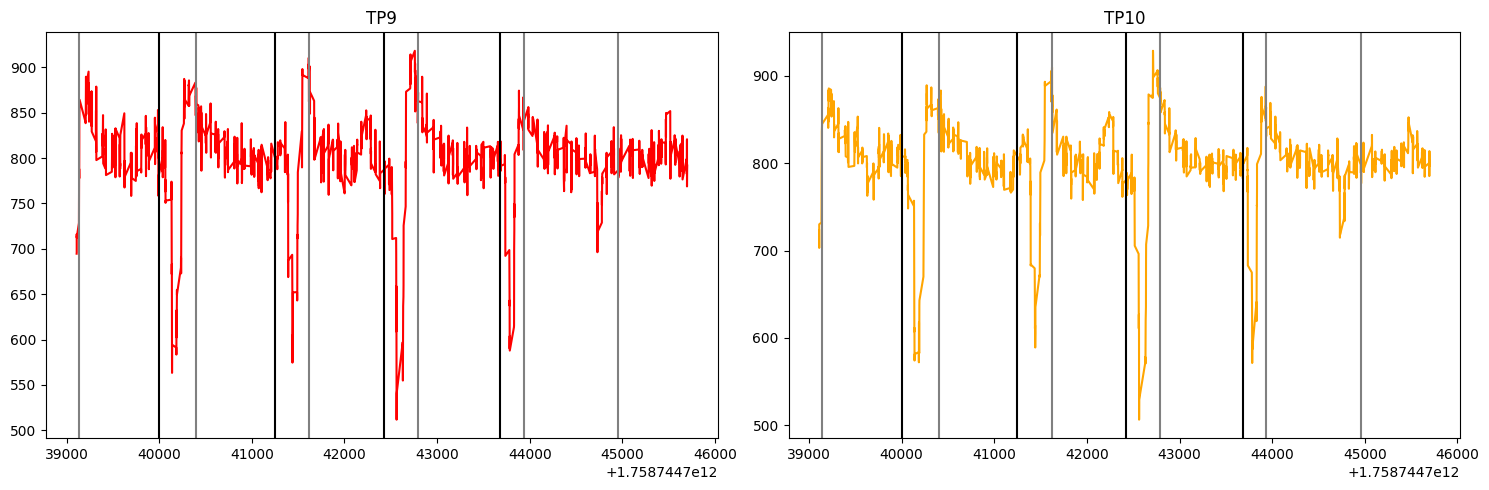

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the EEG data
df = pd.read_csv('./data2/P1/1/calibration/eeg_raw.csv')
df['rel_unix_ms'] = df['unix_ms'] - df['unix_ms'].iloc[0]
df = df[df['rel_unix_ms'] > 5000]
x = df['unix_ms'].to_list()
y1 = df['TP9'].to_list()
y2 = df['TP10'].to_list()

# Read calibration data
cdf = pd.read_csv('./data2/P1/1/calibration/calibration.csv')
cdf = cdf[cdf['event']=='Overlap']
muse_blinks = pd.read_csv('./data2/P1/1/calibration/muse_blinks.csv')
muse_blinks = muse_blinks[muse_blinks['unix_ms'].between(x[0], x[-1])]

fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].plot(x, y1, c='red')
axes[0].set_title('TP9')
axes[1].plot(x, y2, c='orange')
axes[1].set_title('TP10')

for _, row in cdf.iterrows():
    axes[0].axvline(x=row['unix_ms'], c='black')
    axes[1].axvline(x=row['unix_ms'], c='black')
for _, row in muse_blinks.iterrows():
    axes[0].axvline(x=row['unix_ms'], c='gray')
    axes[1].axvline(x=row['unix_ms'], c='gray')

plt.tight_layout()
plt.show()

Note that there's a very distinct pattern at each overlap onset ("Overlap" = when a red circle overlaps a gray circle in the simulation, prompting a blink from the user). There's a distinct valley, then a peak, then a return to normal value. What causes this pattern to generate?

## Steps to Experiment

Let's explore the following:

1. What does the EEG signal look like when the user closes their eyes but doesn't open them again (i.e. keep them closed)?
2. What does the EEG signal look like after having eyes closed, opening them again?
3. What does the EEG signal look like during a normal blink?
4. What does the EEG signal look like during a slow blink?

Let's graph the data, which is stored inside of `src/blink_samples/sample_1.csv`:

In [8]:
import importlib
from components import eeg_handling
importlib.reload(eeg_handling)

eeg, blinks = eeg_handling.read('./blink_samples/sample_1.csv')
raw, processed = eeg_handling.separate(eeg)
display(raw.head(10))

d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)


,unix_sec,unix_ms,rel_sec,rel_ms,TP9,TP10,AF7,AF8
1,1.761155e+09,1761154544432,0.044,44,794.98170,792.16120,784.10254,801.42860
2,1.761155e+09,1761154544433,0.045,45,802.23444,788.53480,853.80950,805.05493
3,1.761155e+09,1761154544433,0.045,45,808.27840,791.75824,824.79850,806.66670
4,1.761155e+09,1761154544434,0.046,46,803.84610,790.95240,776.84980,806.66670
5,1.761155e+09,1761154544434,0.046,46,804.24910,787.72894,787.32600,807.06960
6,1.761155e+09,1761154544434,0.046,46,809.08420,790.95240,846.15390,809.08420
7,1.761155e+09,1761154544436,0.048,48,803.84610,790.95240,846.95970,810.29300
8,1.761155e+09,1761154544436,0.048,48,799.81683,789.74360,780.47620,805.86080
9,1.761155e+09,1761154544437,0.049,49,800.21980,788.53480,755.89746,802.23444
10,1.761155e+09,1761154544437,0.049,49,796.59340,786.52014,791.75824,796.99634


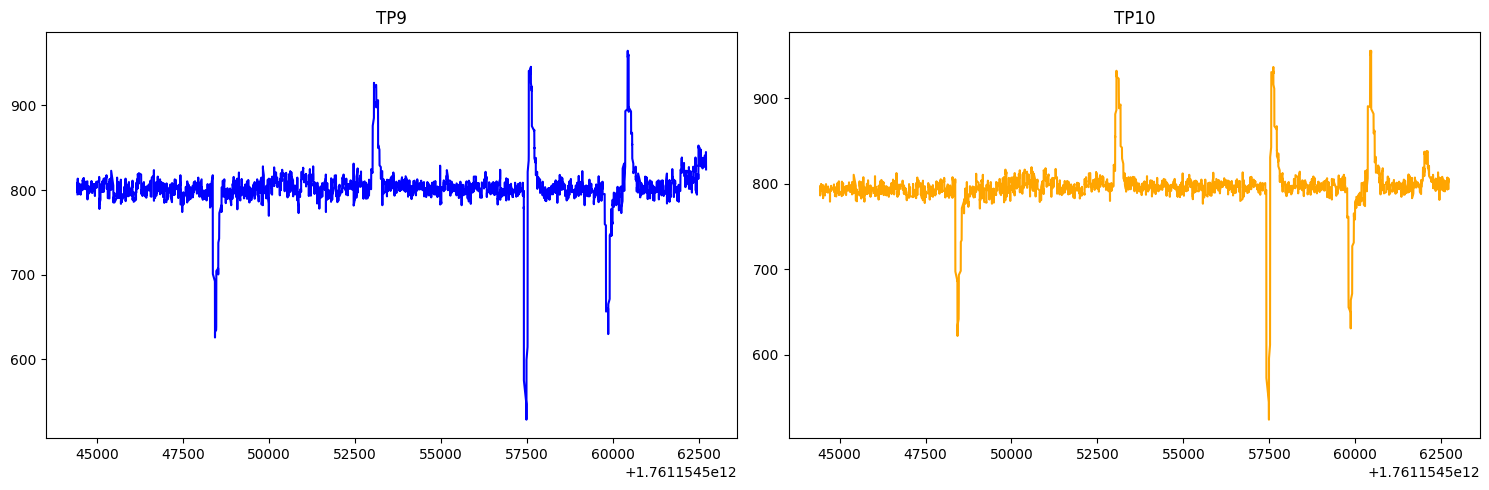

In [9]:
x = raw['unix_ms'].to_list()
y1 = raw['TP9'].to_list()
y2 = raw['TP10'].to_list()

fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].plot(x, y1, c='blue')
axes[0].set_title('TP9')
axes[1].plot(x, y2, c='orange')
axes[1].set_title('TP10')

plt.tight_layout()
plt.show()

The signal appears to look much better when the data is smoothed. Not completely clean, but it's better than the raw signal. The parameters here are a window length of `50` and a poly order of `3`.

## Half-Closed Eyes

What does the signal look like if you attempt to keep eyes half-closed? This data comes from `data/blink_samples/sample_2.csv`. The actions corresponding to this are:

1. Close eyes, keep closed
2. Open eyes from closed
3. Close eyes halfway, keep halfway closed
4. Open eyes from closed
5. Normal blink
6. Slow blink

In [ ]:
eeg2, _ = eeg_handling.read('./blink_samples/sample_2.csv')
raw2, processed2 = eeg_handling.separate(eeg2)

x = raw2['unix_ms'].to_list()
y1 = raw2['TP9'].to_list()
y2 = raw2['TP10'].to_list()

def update_plot(wl=100, poly=3, mode='nearest'):

    # Initialize our plot
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    axes[0].set_title('TP9')
    axes[1].set_title('TP10')

    # original data
    axes[0].plot(x, y1, c='blue', alpha=0.25)
    axes[1].plot(x, y2, c='orange', alpha=0.25)

    # Smooth the data
    y1_smoothed = savgol_filter(y1, window_length=wl, polyorder=poly, mode=mode)
    y2_smoothed = savgol_filter(y2, window_length=wl, polyorder=poly, mode=mode)
    axes[0].plot(x, y1_smoothed, c='blue')
    axes[1].plot(x, y2_smoothed, c='orange')
    
    # Plot
    plt.tight_layout()
    plt.show()

# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=50, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order'),
    mode = Dropdown(options=['mirror', 'constant', 'nearest', 'wrap', 'interp'], value='nearest', description='Mode')
)

d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)


interactive(children=(FloatSlider(value=50.0, description='Window Length', max=200.0, min=10.0), IntSlider(val…

<function __main__.update_plot(wl=100, poly=3, mode='nearest')>

## What's Next?

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[1.separate.ipynb](./1.separate.ipynb)|<i>2.eeg_blink_signals.ipynb</i>|[3.vr_blink_signals.ipynb](./3.vr_blink_signals.ipynb)|